# Data audit

This executed audit reads repository-relative generated public tables. It describes the local extraction only; it does not begin Gate 3 metrics, keyness, or lexicons.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd

root = Path.cwd().resolve()
if not (root / 'pyproject.toml').exists():
    root = root.parent
tables = root / 'reports' / 'tables'
manifest = json.loads((root / 'data' / 'source_manifest.json').read_text(encoding='utf-8'))
audit = pd.read_csv(tables / 'data_audit.csv')
selection = pd.read_csv(tables / 'canonical_selection_summary.csv')
coverage = pd.read_csv(tables / 'coverage_by_congress.csv')
audit

,metric,value
0,records,345477
1,unique_congresses,69
2,denominator_note,record-level counts use all emitted records
3,equal_official_short_total,2
4,equal_official_short_example_cap,50


## Local coverage

The local corpus spans numeric directory shells 6–114, but only 69 Congresses are populated: 6–11, 13–42, and 82–114. Congress 12 and 43–81 are gaps. These are local extraction facts, not universal corpus claims.

In [2]:
coverage[['congress', 'emitted_records']].head(), coverage[['congress', 'emitted_records']].tail()

(   congress  emitted_records
 0         6               84
 1         7               54
 2         8              153
 3         9              156
 4        10              173,
     congress  emitted_records
 64       110            14042
 65       111            13675
 66       112            12299
 67       113            10637
 68       114            11783)

PosixPath('reports/figures/coverage_by_congress.png')

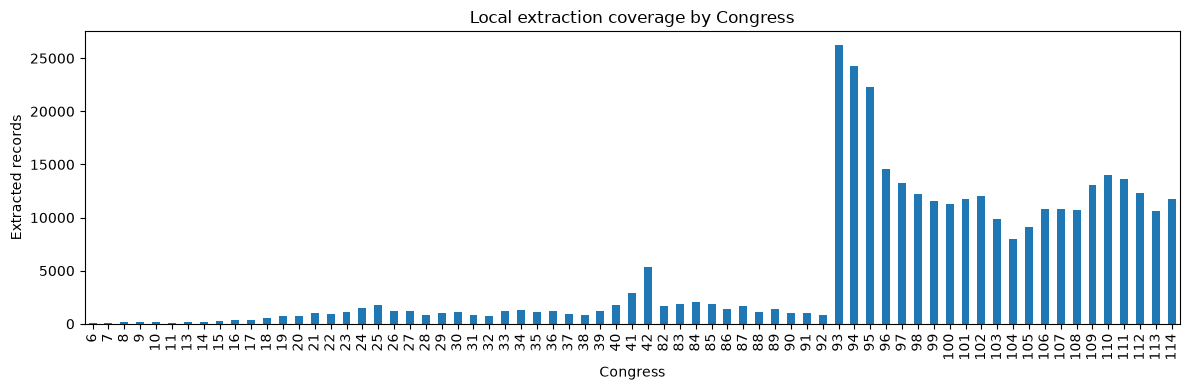

In [3]:
(root / 'reports' / 'figures').mkdir(parents=True, exist_ok=True)
ax = coverage.plot(x='congress', y='emitted_records', kind='bar', legend=False, figsize=(12, 4))
ax.set(xlabel='Congress', ylabel='Extracted records', title='Local extraction coverage by Congress')
plt.tight_layout()
figure_path = Path('reports') / 'figures' / 'coverage_by_congress.png'
plt.savefig(root / figure_path, dpi=150)
figure_path

## Extraction and title coverage

The following public tables provide all-record accounting, missing-title coverage, and candidate disagreements/multiplicity.

In [4]:
missingness = pd.read_csv(tables / 'title_missingness_and_pairs.csv')
disagreement = pd.read_csv(tables / 'title_source_disagreement.csv')
multiplicity = pd.read_csv(tables / 'non_portion_candidate_multiplicity.csv')
display(missingness)
display(disagreement)
multiplicity.head(12)

,diagnostic,count,denominator
0,missing_official_title,276,345477
1,missing_popular_title,342667,345477
2,missing_short_title,225679,345477
3,official_and_short_both_missing,276,345477
4,official_and_short_equal,2,345477
5,official_and_short_distinct_or_one_missing,345199,345477


,category,count,denominator
0,official_exact_single_match,342418,345477
1,official_match_with_distinct_alternatives,2783,345477
2,official_disagrees_with_candidates,0,345477
3,official_top_level_only,0,345477
4,official_candidate_only,0,345477
5,official_absent_from_both,276,345477
6,short_exact_single_match,112402,345477
7,short_match_with_distinct_alternatives,7396,345477
8,short_disagrees_with_candidates,0,345477
9,short_top_level_only,0,345477


,source,candidate_entry_count,distinct_text_count,count,denominator
0,display,0,0,333694,345477
1,display,1,1,11781,345477
2,display,2,1,2,345477
3,official,0,0,276,345477
4,official,1,1,342405,345477
5,official,2,1,13,345477
6,official,2,2,2736,345477
7,official,3,2,2,345477
8,official,3,3,45,345477
9,popular,0,0,342667,345477


## Canonical selection and stage alignment

Canonical official and short titles are the source-provided top-level fields. Records without both are excluded from the pair table. Popular/display titles are comparison-only; `is_for_portion` entries remain traceable but are not candidates. Stage sets match non-portion entries by type and exact top-level text; no stage ordering is inferred.

In [5]:
stage_distribution = pd.read_csv(tables / 'top_level_matching_stage_distributions.csv')
alignment = pd.read_csv(tables / 'shared_stage_distribution.csv')
multiple_stages = pd.read_csv(tables / 'multiple_matching_stages.csv')
display(selection)
display(alignment)
display(multiple_stages)
stage_distribution.head(12)

,metric,value
0,rule,top-level official_title and short_title
1,total_input,345477
2,eligible_pairs,119798
3,missing_official_only,0
4,missing_short_only,225403
5,missing_both,276
6,shared_stage,115134
7,no_shared_stage,4664
8,popular_display_policy,comparison-only; never canonical fallbacks
9,portion_policy,preserved in titles_json; never canonical cand...


,status,count,denominator_eligible_pairs
0,shared_stage,115134,119798
1,no_shared_stage,4664,119798


,source,records_with_multiple_matching_stages,denominator_all_records
0,official,15,345477
1,short,10966,345477
2,popular,0,345477


,source,matching_stages_json,count,denominator_all_records
0,official,"[""agreed to by house and senate""]",2,345477
1,official,"[""amended by house"", ""amended by senate""]",2,345477
2,official,"[""amended by house""]",789,345477
3,official,"[""amended by senate""]",624,345477
4,official,"[""enacted""]",17262,345477
5,official,"[""introduced"", ""agreed to by house and senate""]",3,345477
6,official,"[""introduced"", ""amended by house""]",6,345477
7,official,"[""introduced"", ""amended by senate""]",2,345477
8,official,"[""introduced"", ""enacted""]",1,345477
9,official,"[""introduced"", ""other bill versions""]",1,345477


## Multiple-distinct-candidate matching stages

This public table is restricted to records with multiple distinct candidates for each source. A record contributes once per unique `as` label whose candidate text exactly matches that source’s top-level field, so counts can exceed the source-specific denominator. In this rerun, no matching official-title label is `introduced`; this is an archive-specific observation, not a source-authority or stage-ordering claim.

In [6]:
multiple_distinct_stage_selection = pd.read_csv(tables / 'multiple_distinct_candidate_stage_selection.csv')
display(multiple_distinct_stage_selection)

,source,matching_stage_json,count,denominator_records_with_multiple_distinct_candidates,multiple_stage_semantics
0,official,"""agreed to by house and senate""",2,2783,records contribute once per unique matching st...
1,official,"""amended by house""",791,2783,records contribute once per unique matching st...
2,official,"""amended by senate""",626,2783,records contribute once per unique matching st...
3,official,"""enacted""",1366,2783,records contribute once per unique matching st...
4,short,"""conference report""",2,7396,records contribute once per unique matching st...
5,short,"""enacted""",1268,7396,records contribute once per unique matching st...
6,short,"""introduced""",3943,7396,records contribute once per unique matching st...
7,short,"""passed house""",1503,7396,records contribute once per unique matching st...
8,short,"""passed senate""",1277,7396,records contribute once per unique matching st...
9,short,"""reported to house""",888,7396,records contribute once per unique matching st...
